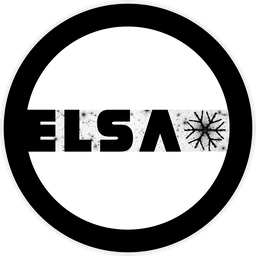

# GELSA tutorial: 1D spectra decontamination

**[ELSA](https://elsa-euclid.github.io/): Euclid Legacy Science Advanced analysis tools**

Extract 1D spectra with decontamination

Copyright 2024–2026 Ben Granett and the GELSA contributors

This file is subject to the terms and conditions defined in LICENSE.txt, which forms part of this source code package. No part of the package, including this file, may be copied, modified, propagated, or distributed except according to the terms contained in LICENSE.txt.

<br clear="left">

In [17]:
import numpy as np
from matplotlib import pyplot as plt
from tqdm.auto import tqdm

from astroquery.esa.euclid.core import EuclidClass

import azulero.process as proc
from azulero.image import color

import gelsa
from gelsa import decontam
from gelsa import decontam_utils
from gelsa.esa import euclid_archive

print(f"Gelsa version {gelsa.version.version}")

Gelsa version 4.0


## 1. Initialize Euclid archive connection and GELSA

In [2]:
Euclid = EuclidClass(environment='IDR')
Euclid.login(credentials_file='/media/home/my_workspace/password')

INFO: Login to Euclid TAP server: easidr.esac.esa.int:443/tap-server/tap/ [astroquery.esa.euclid.core]
INFO: OK [astroquery.utils.tap.core]
INFO: Login to Euclid data service: easidr.esac.esa.int:443/sas-dd/tap-server/ [astroquery.esa.euclid.core]
INFO: OK [astroquery.utils.tap.core]
INFO: Login to Euclid cutout service: easidr.esac.esa.int:443/sas-cutout/tap-server/ [astroquery.esa.euclid.core]
INFO: OK [astroquery.utils.tap.core]


In [3]:
EA = euclid_archive.EuclidArchive(Euclid)

In [4]:
# initialize the gelsa class
G = gelsa.Gelsa()

## 2. Set a target

In [6]:
ra = 268.5026717144212
dec = 63.7361903645274
redshift = 0.387

survey = 'deep_visits'
patch_id = 57

# decontamination parameters
flux_cut_microjy = 1e6 * 10**(-0.4*(20.5 - 8.9))   # flux limit forcontaminant modeling

## 3. Retrieve SIR 1D spectrum

In [7]:
sir_pack_list = EA.load_sir_combined_spectrum(ra, dec, patch_id=patch_id, survey=survey)
print(f"got {len(sir_pack_list)} match!")

got 1 match!


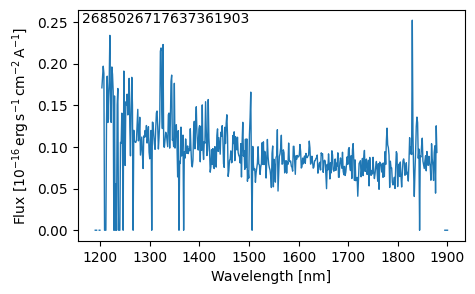

In [8]:
def plot_sir_spectrum(data=None, header=None, maskbits=32+64, lw=1, c=None, **plotparams):
    """ """
    sir_wavelength = data['WAVELENGTH']
    sir_signal = data['SIGNAL']
    sir_mask = data['MASK']
    valid = np.bitwise_and(sir_mask, maskbits) == 0
    sir_signal = np.ma.array(sir_signal, mask=~valid)
    plt.plot(sir_wavelength/10, sir_signal, lw=lw, c=c, **plotparams)
    plt.xlabel("Wavelength [nm]")
    _ = plt.ylabel("Flux [${\\rm 10^{-16}\\,erg\\,s^{-1}\\,cm^{-2}\\,A^{-1}}$]")
    plt.text(0.01, 0.99, header['object_id'], va='top', 
             transform=plt.gca().transAxes)
    
plt.figure(figsize=(5,3))
plot_sir_spectrum(**sir_pack_list[0])

## 3. Load catalogs and images for decontamination

In [9]:
decon = decontam.Decontamination()
decon.add_target(ra, dec)

cat = EA.load_mer_catalog(ra, dec, survey=survey, patch_id=patch_id, 
                          radius_deg=0.2)
cat.add_index('OBJECT_ID')
cat.add_index('SEGMENTATION_MAP_ID')

tile_list = np.unique(list(cat['TILE_INDEX']))

sel = cat['FLUX_H_TEMPLFIT'] > flux_cut_microjy
cat = cat[sel]

decon.add_catalog(cat)
print(f"tiles: {tile_list}")
print(f"loaded catalog rows: {len(decon.cat)}")

tiles: [102157631 102157632 102157954 102157955]
loaded catalog rows: 20444


In [10]:
for tile_ in tile_list:
    image_, segmap_, wcs_ = EA.load_tile_image(tile_, patch_id)
    decon.add_image(image_, segmap_, wcs_, tile=tile_)
    print(f"loaded tile {tile_}")
print(f"loaded {len(decon.image_list)} tile images")

loaded tile 102157631
loaded tile 102157632
loaded tile 102157954
loaded tile 102157955
loaded 4 tile images


## Retrieve the SIR frame file list

This cell submits a query to the Euclid archive for SIR frames that are near to the specified RA, Dec position.

In [11]:
sir_path_list = EA.query_sir_frames(ra, dec, patch_id=patch_id, radius_deg=0.5)

frame_list = []
for path in sir_path_list:
    frame_list.append(G.load_frame(path))

decon.add_frame(*frame_list)


print(f"Found this many SIR frames: {len(decon.frame_list)}")

Found this many SIR frames: 6


In [18]:
decon.params['reg_lambda_list'] = [100,]
decon.params['reg_floor'] = 0.001

with tqdm() as progress:
    results = decon.fit(sigma_clip=5, masking_iterations=1, nthreads=4,
                   progress_hook=progress.update)

0it [00:00, ?it/s]

(0.0, 0.25)

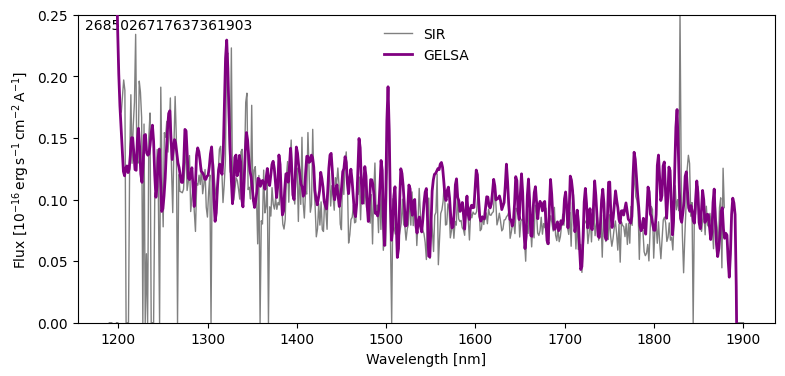

In [19]:
pack = results[0]
gal_ = pack[0][0]

plt.figure(figsize=(9,4))
plot_sir_spectrum(**sir_pack_list[0], c='grey', label='SIR')
plt.plot(gal_.wavelength/10, gal_.sed_params*1e16, lw=2, c='purple', zorder=10, label='GELSA')
plt.legend(frameon=False)
plt.ylim(0,0.25)

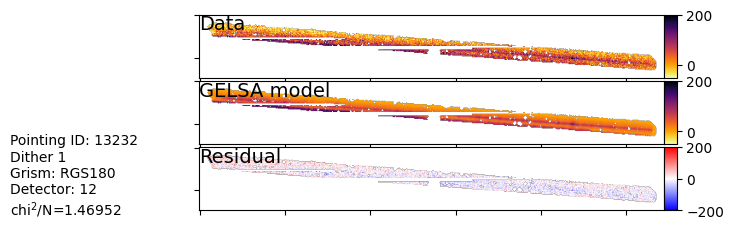

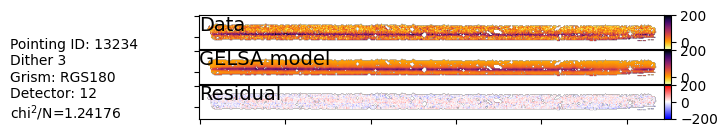

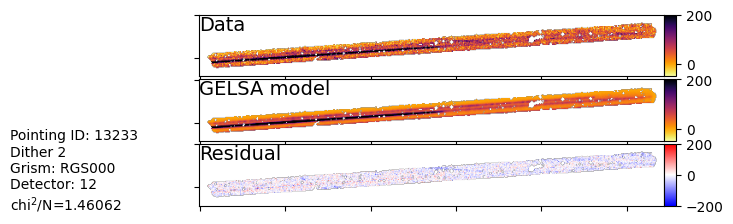

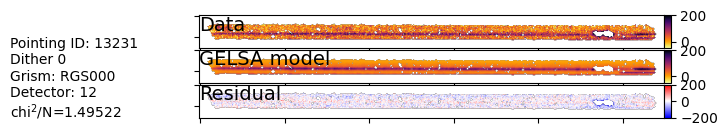

In [14]:
import importlib
importlib.reload(decontam_utils)

for pack in results:
    # fig = plt.figure(figsize=(10,10))
    decontam_utils.plot2d_target(pack[1], decon.specimager_list, vmax=200)

---

## Acknowledgements

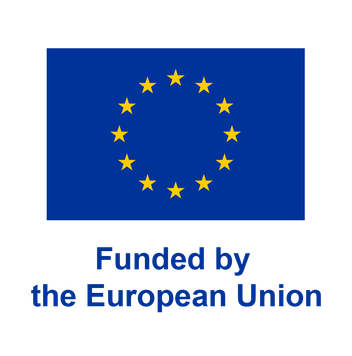

Please include the acknowledgement for the ELSA project below in all publications.

"ELSA: Euclid Legacy Science Advanced analysis tools" (Grant Agreement no. 101135203) is funded by the European Union. Views and opinions expressed are however those of the author(s) only and do not necessarily reflect those of the European Union or Innovate UK. Neither the European Union nor the granting authority can be held responsible for them. UK participation is funded through the UK Horizon guarantee scheme under Innovate UK grant 10093177.

<br clear="left">